<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/ML%20Exp4%20Prepruning%20of%20Decision%20Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Goal of Decision Tree**

* **Prediction:** To accurately predict the value or class label of a target variable based on input features.

* **Decision Making:** To model the decision-making process as a tree structure where each internal node represents a feature-based decision and each leaf node represents an outcome.

* **Classification and Regression:** To solve classification problems by categorizing data points and regression problems by predicting continuous outputs.

* **Interpretability:** To offer a simple and transparent model structure that is easy to understand and explain.

* **Feature Importance:** To identify and rank the most important features influencing predictions.

* **Data Handling:** To efficiently handle both numerical and categorical data without requiring extensive preprocessing.

* **Generalization:** To build a model that generalizes well to unseen data by learning useful patterns from the training data.

* **Visualization:** To provide a clear visual representation of the decision-making process, facilitating debugging and insight into the model’s logic.

**Splitting Criteria** (like **Gini Index or Information Gain**) are metrics used at each decision tree node to mathematically determine the best feature and threshold to partition the data. The goal is to **maximize the purity** of the resulting child nodes, ensuring each node is dominated by a single class.

**Feature Importance** is a score assigned to each feature indicating its predictive power, usually calculated as the **normalized total reduction in impurity** the feature achieved across the entire tree. This is vital for **model interpretation** and simplifies the model by identifying and allowing for the removal of irrelevant input features.

# Step 1: Import Libraries and Load Data

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris(as_frame=True)
iris_df = iris.frame

# Prepare features and target
X = iris_df.drop('target', axis=1)
y = iris_df['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train default Decision Tree
dt_default = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_default.fit(X_train, y_train)
y_pred_default = dt_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_pred_default)

# Print default tree metrics
print(f"\n🔹 Default Decision Tree Accuracy: {accuracy_default:.4f}")
print(f"Max Depth: {dt_default.get_depth()}")
print(f"Min Samples Split: {dt_default.get_params()['min_samples_split']}")
print(f"Min Samples Leaf: {dt_default.get_params()['min_samples_leaf']}")
print(f"Number of Leaf Nodes: {dt_default.get_n_leaves()}")

# Default Model Parameters (No Tuning)
default_split = dt_default.get_params()['min_samples_split']
default_leaf = dt_default.get_params()['min_samples_leaf']
print("\n Default Model Parameters (No Tuning):")
print(f"Min Samples Split (default): {default_split}")
print(f"Min Samples Leaf (default): {default_leaf}")
print(f"Accuracy with default split & leaf: {accuracy_default:.4f}")


🔹 Default Decision Tree Accuracy: 1.0000
Max Depth: 5
Min Samples Split: 2
Min Samples Leaf: 1
Number of Leaf Nodes: 9

 Default Model Parameters (No Tuning):
Min Samples Split (default): 2
Min Samples Leaf (default): 1
Accuracy with default split & leaf: 1.0000


# Step 2: Pre-pruning via Max Depth

It performs **pre-pruning** by training Decision Trees iteratively while restricting the maximum depth (max_depth). This controls model complexity, preventing overfitting. The loop finds the specific depth that yields the **highest accuracy** on the test set, thus identifying the optimal level of regularization.

In [ ]:
accuracy_max_depth = []
for depth in range(1, 11):
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=0)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracy_max_depth.append({'Max Depth': depth, 'Accuracy': acc})

df_max_depth = pd.DataFrame(accuracy_max_depth)
best_depth_row = df_max_depth.loc[df_max_depth['Accuracy'].idxmax()]

print("\n Accuracy for Different Max Depths:")
print(df_max_depth.to_markdown(index=False))
print(f"\n Best Accuracy at Max Depth = {best_depth_row['Max Depth']} → Accuracy = {best_depth_row['Accuracy']:.4f}")


 Accuracy for Different Max Depths:
|   Max Depth |   Accuracy |
|------------:|-----------:|
|           1 |   0.566667 |
|           2 |   0.966667 |
|           3 |   0.966667 |
|           4 |   1        |
|           5 |   1        |
|           6 |   1        |
|           7 |   1        |
|           8 |   1        |
|           9 |   1        |
|          10 |   1        |

 Best Accuracy at Max Depth = 4.0 → Accuracy = 1.0000


# Step 3: Pre-pruning via Min Samples Split and Min Samples Leaf

It explores the impact of two constraints: **min_samples_split** and **min_samples_leaf**. It loops through various combinations of these hyperparameters, training a new Decision Tree for each set. This process identifies the **combination of minimum node/leaf sizes** that yields the **highest generalization accuracy** on the test set.

In [ ]:
accuracy_split_leaf = []
for split in range(2, 21, 2):
    for leaf in range(1, 11):
        model = DecisionTreeClassifier(criterion='entropy', min_samples_split=split, min_samples_leaf=leaf, random_state=0)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        accuracy_split_leaf.append({'Min Samples Split': split, 'Min Samples Leaf': leaf, 'Accuracy': acc})

df_split_leaf = pd.DataFrame(accuracy_split_leaf)
best_split_leaf_row = df_split_leaf.loc[df_split_leaf['Accuracy'].idxmax()]

print("\n Accuracy for Min Samples Split & Min Samples Leaf:")
print(df_split_leaf.to_markdown(index=False))
print(f"\n Best Accuracy at Split = {best_split_leaf_row['Min Samples Split']}, Leaf = {best_split_leaf_row['Min Samples Leaf']} → Accuracy = {best_split_leaf_row['Accuracy']:.4f}")

# Average Accuracy by Min Samples Split
avg_accuracy_by_split = df_split_leaf.groupby('Min Samples Split')['Accuracy'].mean().reset_index()
print("\n Average Accuracy by Min Samples Split:")
print(avg_accuracy_by_split.to_markdown(index=False))


 Accuracy for Min Samples Split & Min Samples Leaf:
|   Min Samples Split |   Min Samples Leaf |   Accuracy |
|--------------------:|-------------------:|-----------:|
|                   2 |                  1 |   1        |
|                   2 |                  2 |   0.966667 |
|                   2 |                  3 |   1        |
|                   2 |                  4 |   1        |
|                   2 |                  5 |   1        |
|                   2 |                  6 |   0.966667 |
|                   2 |                  7 |   0.966667 |
|                   2 |                  8 |   0.966667 |
|                   2 |                  9 |   0.966667 |
|                   2 |                 10 |   0.966667 |
|                   4 |                  1 |   0.966667 |
|                   4 |                  2 |   0.966667 |
|                   4 |                  3 |   1        |
|                   4 |                  4 |   1        |
|                  

# Step 4: Pre-pruning via Max Leaf Nodes
It performs pre-pruning by iteratively restricting the **max_leaf_nodes** hyperparameter. This directly **limits the overall size of the tree**, which is a powerful way to control complexity and prevent the tree from growing unnecessary branches. The loop determines the optimal maximum number of leaf nodes that maximizes the test set accuracy.

In [ ]:
accuracy_leaf_nodes = []
for nodes in range(8, 1, -1):
    model = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=nodes, random_state=0)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracy_leaf_nodes.append({'Max Leaf Nodes': nodes, 'Accuracy': acc})

df_leaf_nodes = pd.DataFrame(accuracy_leaf_nodes)
best_leaf_nodes_row = df_leaf_nodes.loc[df_leaf_nodes['Accuracy'].idxmax()]

print("\n Accuracy for Max Leaf Nodes:")
print(df_leaf_nodes.to_markdown(index=False))
print(f"\n Best Accuracy at Max Leaf Nodes = {best_leaf_nodes_row['Max Leaf Nodes']} → Accuracy = {best_leaf_nodes_row['Accuracy']:.4f}")


 Accuracy for Max Leaf Nodes:
|   Max Leaf Nodes |   Accuracy |
|-----------------:|-----------:|
|                8 |   0.966667 |
|                7 |   0.966667 |
|                6 |   0.966667 |
|                5 |   1        |
|                4 |   1        |
|                3 |   0.966667 |
|                2 |   0.566667 |

 Best Accuracy at Max Leaf Nodes = 5.0 → Accuracy = 1.0000


# Step 5: Summarize Results and Visualize


 Summary of Best Prepruning Configurations:
Default Tree Accuracy: 1.0
Best Max Depth: {'Max Depth': 4.0, 'Accuracy': 1.0}
Best Min Samples Split & Leaf: {'Min Samples Split': 2.0, 'Min Samples Leaf': 1.0, 'Accuracy': 1.0}
Best Max Leaf Nodes: {'Max Leaf Nodes': 5.0, 'Accuracy': 1.0}


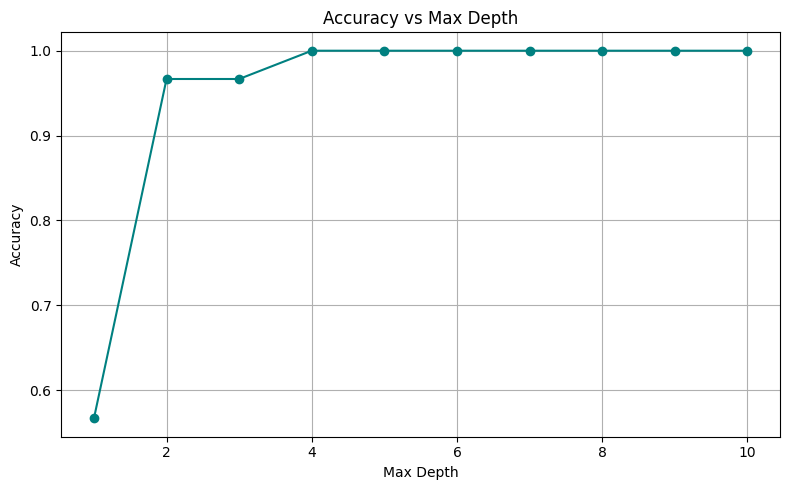

In [ ]:
print("\n Summary of Best Prepruning Configurations:")
summary = {
    'Default Tree Accuracy': accuracy_default,
    'Best Max Depth': best_depth_row.to_dict(),
    'Best Min Samples Split & Leaf': best_split_leaf_row.to_dict(),
    'Best Max Leaf Nodes': best_leaf_nodes_row.to_dict()
}
for key, val in summary.items():
    print(f"{key}: {val}")

# Optional: Visualize Accuracy vs Max Depth
plt.figure(figsize=(8, 5))
plt.plot(df_max_depth['Max Depth'], df_max_depth['Accuracy'], marker='o', color='teal')
plt.title('Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Pitfalls of Decision Trees**

*  **Overfitting:** Decision trees can become too complex and capture noise in the training data, leading to poor generalization on unseen data.

* **High Variance / Instability:** Small changes in the data can produce significantly different trees.

* **Bias Toward Dominant Classes:** Trees can be biased when classes are imbalanced, favoring the majority class.

* **Greedy Nature:** The splitting decisions are locally optimal and may not result in the globally best tree.

* **Lack of Smoothness:** Decision trees create discrete step-like boundaries which may not suit problems needing smooth predictions.

* **Limited Expressiveness:** They struggle to capture complex or linear relationships compared to other models.

* **Computational Expense**: Large datasets with many features can make training slow.



# **Why Do We Need to Prune Trees?**

* **Control Overfitting:** Pruning reduces tree complexity by removing branches that capture noise.

* **Improve Generalization:** It helps the model perform better on unseen data.

* **Reduce Variance:** Pruning provides more stable and consistent decision boundaries.

* **Simplify Model:** Makes the tree easier to interpret and reduces computational cost.

* **Avoid Overly Deep Trees:** Helps in avoiding trees that grow too deep due to noise or minor fluctuations.

# **Comparison of ID3, C4.5, and CART**

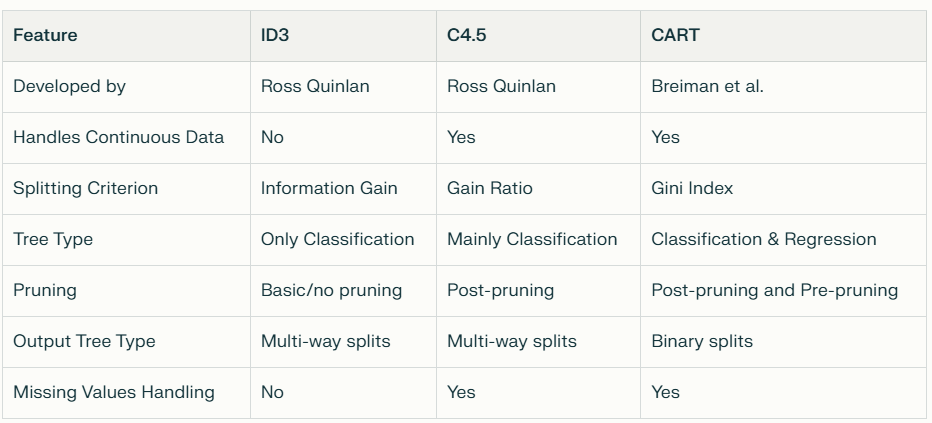